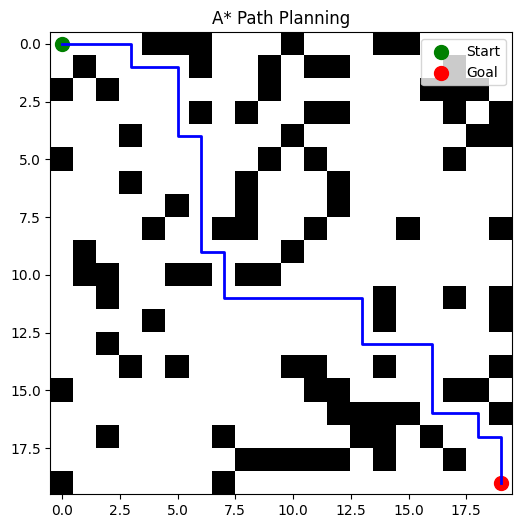

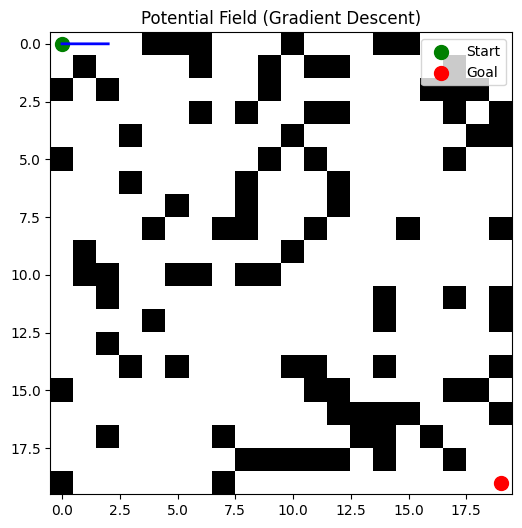

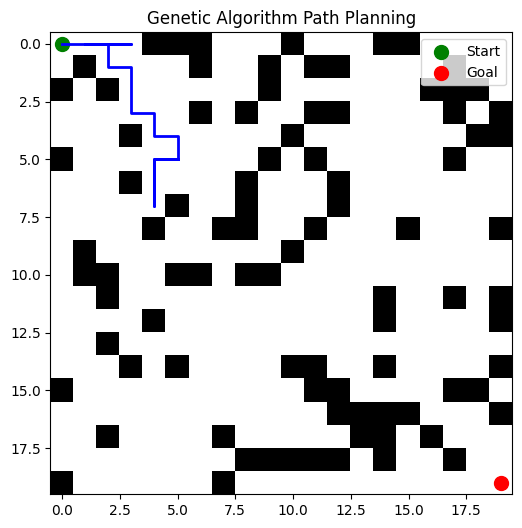

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import random

# ================================================================
# Environment Setup
# ================================================================
GRID_SIZE = 20
OBSTACLE_RATIO = 0.2  # % of grid cells that are obstacles

np.random.seed(42)
grid = np.zeros((GRID_SIZE, GRID_SIZE))
obstacles = np.random.rand(GRID_SIZE, GRID_SIZE) < OBSTACLE_RATIO
grid[obstacles] = 1  # Mark obstacles

start = (0, 0)
goal = (GRID_SIZE - 1, GRID_SIZE - 1)
grid[start] = 0
grid[goal] = 0


# ================================================================
# Utility Functions
# ================================================================
def plot_path(path, title, grid):
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap='gray_r')
    plt.title(title)
    plt.scatter(start[1], start[0], c='green', s=100, label='Start')
    plt.scatter(goal[1], goal[0], c='red', s=100, label='Goal')

    if path:
        y, x = zip(*path)
        plt.plot(x, y, c='blue', linewidth=2)
    plt.legend()
    plt.show()


def neighbors(node):
    """Return 4-connected neighbors."""
    r, c = node
    steps = [(r+1, c), (r-1, c), (r, c+1), (r, c-1)]
    valid = [
        (rr, cc) for rr, cc in steps
        if 0 <= rr < GRID_SIZE and 0 <= cc < GRID_SIZE and grid[rr, cc] == 0
    ]
    return valid


# ================================================================
# 1️⃣ A* Path Planning
# ================================================================
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar(start, goal):
    open_set = []
    heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start))
    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, cost, current = heapq.heappop(open_set)
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for n in neighbors(current):
            new_cost = cost + 1
            if n not in g_score or new_cost < g_score[n]:
                g_score[n] = new_cost
                f = new_cost + heuristic(n, goal)
                heapq.heappush(open_set, (f, new_cost, n))
                came_from[n] = current
    return None


# ================================================================
# 2️⃣ Gradient Descent (Potential Fields)
# ================================================================
def potential_field_path(start, goal, grid, step_size=1.0, iterations=2000):
    x, y = np.array(start, dtype=float)
    goal = np.array(goal, dtype=float)
    path = [tuple(start)]

    def potential(px, py):
        # Attractive potential to goal
        attr = np.hypot(goal[0]-px, goal[1]-py)
        # Repulsive potential from obstacles
        rep = 0
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if grid[r, c] == 1:
                    dist = np.hypot(px - r, py - c)
                    if dist < 3:  # influence radius
                        rep += 1.0 / (dist + 1e-3)
        return attr + rep

    for _ in range(iterations):
        # Numerical gradient
        dx = (potential(x+1, y) - potential(x-1, y)) / 2
        dy = (potential(x, y+1) - potential(x, y-1)) / 2
        grad = np.array([dx, dy])

        # Gradient descent update
        pos = np.array([x, y]) - step_size * grad
        x, y = np.clip(pos, 0, GRID_SIZE-1)
        path.append((int(round(x)), int(round(y))))

        if np.linalg.norm(goal - pos) < 1:
            break

    return path


# ================================================================
# 3️⃣ Genetic Algorithm Path Planning
# ================================================================
def ga_path(start, goal, grid, pop_size=50, generations=200, mutation_rate=0.2):
    def random_path():
        path = [start]
        for _ in range(GRID_SIZE):
            next_steps = neighbors(path[-1])
            if not next_steps:
                break
            path.append(random.choice(next_steps))
            if path[-1] == goal:
                break
        return path

    def fitness(path):
        if path[-1] != goal:
            return float('inf')
        length = len(path)
        collisions = sum([1 for p in path if grid[p] == 1])
        return length + 10 * collisions

    population = [random_path() for _ in range(pop_size)]

    for _ in range(generations):
        population.sort(key=fitness)
        new_pop = population[:10]  # keep top 10
        while len(new_pop) < pop_size:
            p1, p2 = random.sample(population[:25], 2)
            cut = random.randint(1, min(len(p1), len(p2)) - 1)
            child = p1[:cut] + p2[cut:]
            if random.random() < mutation_rate:
                idx = random.randint(0, len(child) - 1)
                child[idx] = random.choice(neighbors(child[idx]))
            new_pop.append(child)
        population = new_pop

        if fitness(population[0]) < GRID_SIZE:
            break

    return population[0]


# ================================================================
# Run All Algorithms
# ================================================================
astar_path = astar(start, goal)
pf_path = potential_field_path(start, goal, grid)
ga_best = ga_path(start, goal, grid)

# ================================================================
# Visualize
# ================================================================
plot_path(astar_path, "A* Path Planning", grid)
plot_path(pf_path, "Potential Field (Gradient Descent)", grid)
plot_path(ga_best, "Genetic Algorithm Path Planning", grid)
